# 🏠 Challenge #02: House Prices — From Scratch

**Authors:** Zakariae
**Date:**  
**Time Limit:** 5 hours   
**Rules:** No scikit-learn for model building. Only NumPy, Pandas, Matplotlib.  
**Dataset:** California Housing (20,640 districts, predict median_house_value)

## Step 0: Imports & Data Loading

In [83]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

%matplotlib inline

In [84]:
df = pd.read_csv("data/housing.csv")
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Shape: {df.shape}")
df.head()

Shape: (20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-119.01,36.06,25.0,1505.0,NaN,1392.0,359.0,1.6812,47700.0,INLAND
1,-119.46,35.14,30.0,2943.0,NaN,1565.0,584.0,2.5313,45800.0,INLAND
2,-122.44,37.80,52.0,3830.0,NaN,1310.0,963.0,3.4801,500001.0,NEAR BAY
3,-118.72,34.28,17.0,3051.0,NaN,1705.0,495.0,5.7376,218600.0,<1H OCEAN
4,-121.93,36.62,34.0,2351.0,NaN,1063.0,428.0,3.7250,278000.0,NEAR OCEAN


## Step 1: Problem Framing (30 min) ⏱️

**What am I predicting?**  
- it s a regression problem , i m trying to predict "median_house_value" which is a numerical value

**What metric defines success?**  
- MSE/MAE/R_squared

**Business context:**  
- this will help the housing market to give the best price for a house

## Step 2: EDA (45 min) ⏱️

<Axes: ylabel='Frequency'>

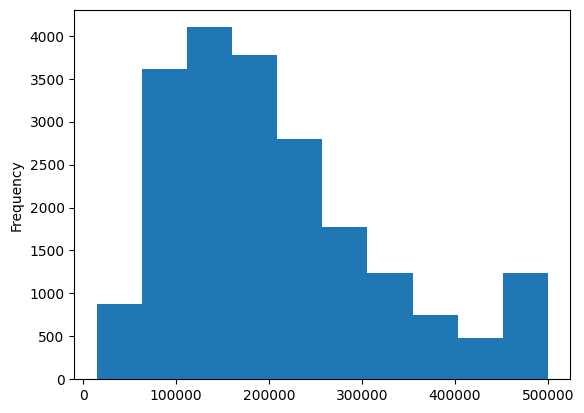

In [85]:
# Target distribution
df['median_house_value'].plot(kind='hist')


<Axes: >

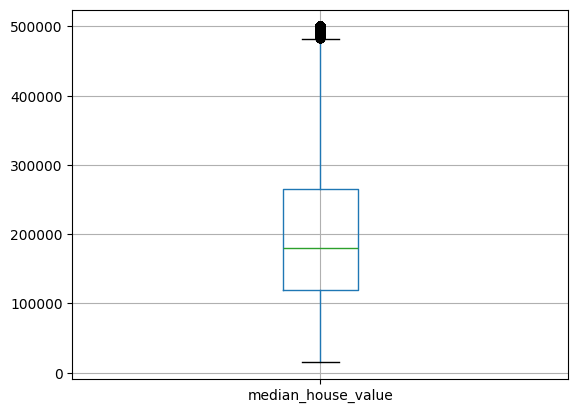

In [86]:
df.boxplot(['median_house_value'])

array([[<Axes: title={'center': 'longitude'}>,
        <Axes: title={'center': 'latitude'}>,
        <Axes: title={'center': 'housing_median_age'}>],
       [<Axes: title={'center': 'total_rooms'}>,
        <Axes: title={'center': 'total_bedrooms'}>,
        <Axes: title={'center': 'population'}>],
       [<Axes: title={'center': 'households'}>,
        <Axes: title={'center': 'median_income'}>,
        <Axes: title={'center': 'median_house_value'}>]], dtype=object)

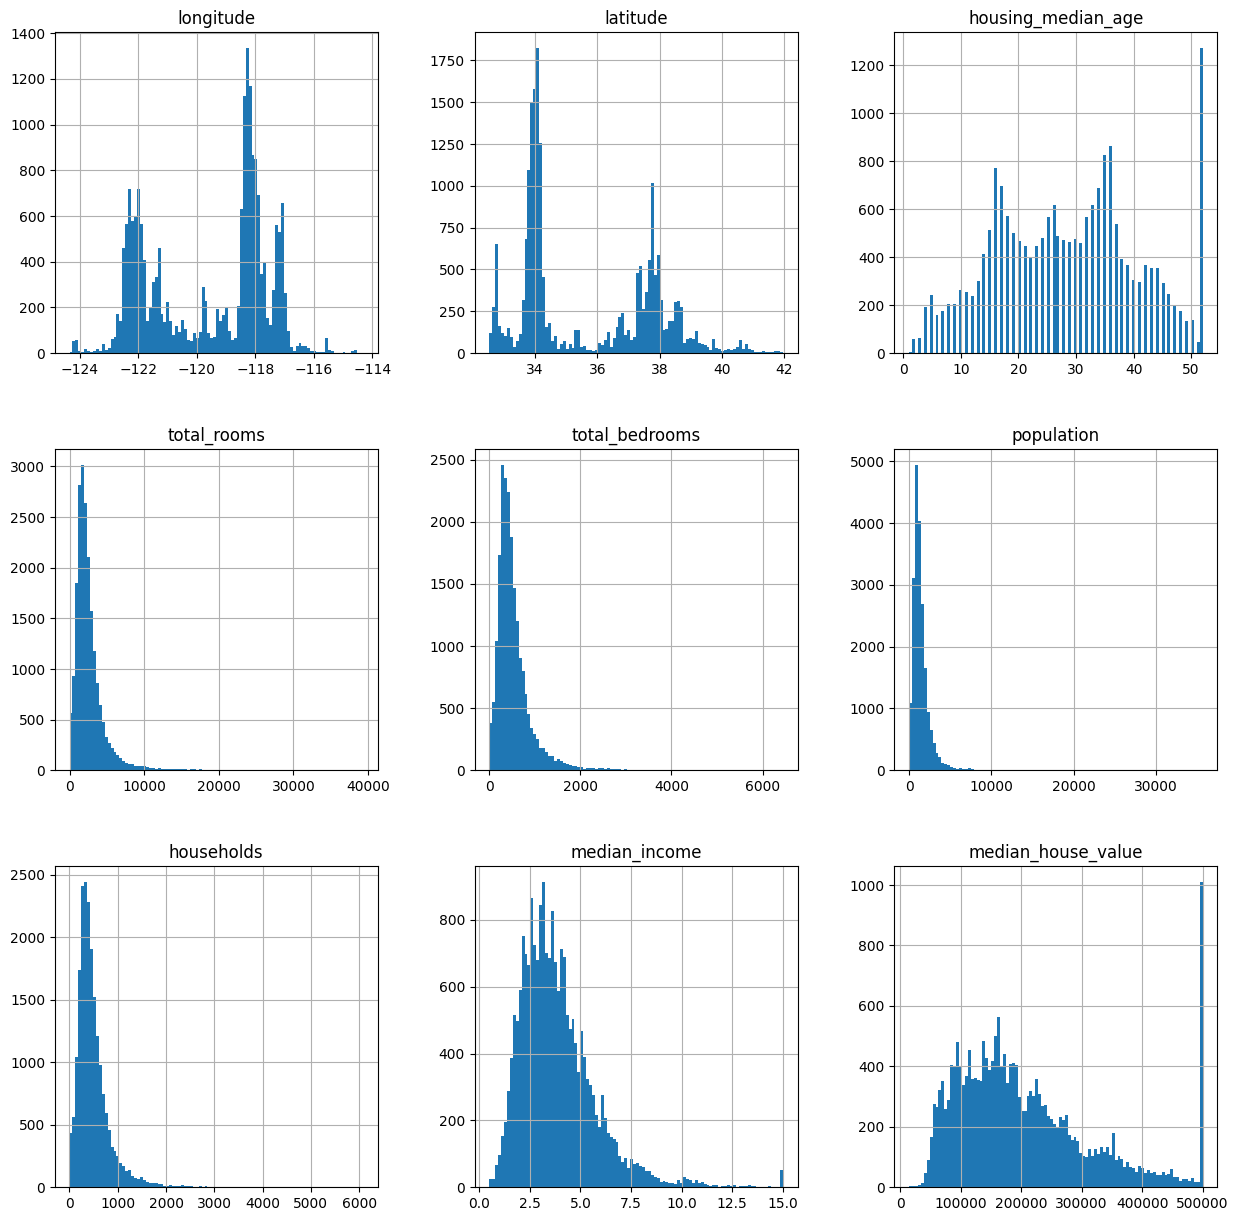

In [87]:
df.hist(bins=100, figsize=(15, 15))

In [88]:
df.info() 

# Data types : 9 float / 1 str
# Missing values: total_bedrooms(floats) 

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [7]:
# Numerical summary
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


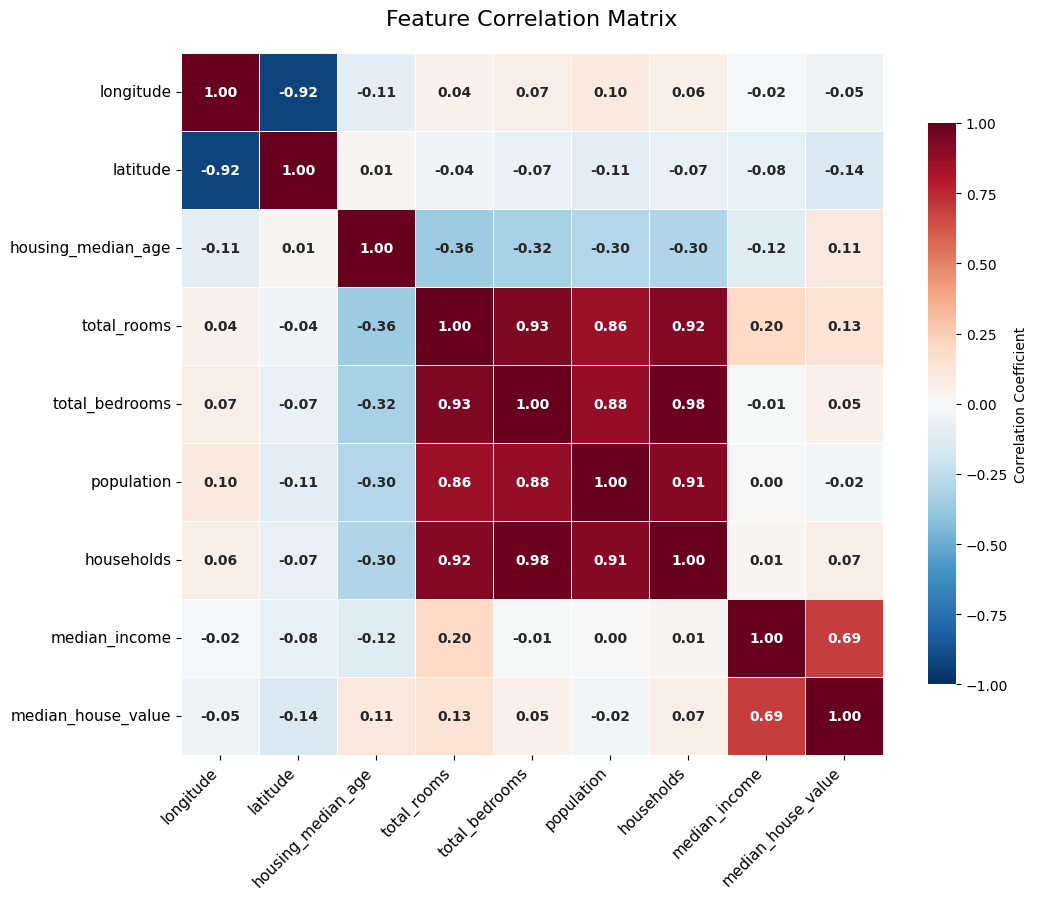

In [8]:
# Correlation heatmap
plt.figure(figsize=(11, 9))

corr_matrix = df.select_dtypes(include=[np.number]).corr()

sns.heatmap(corr_matrix,
            annot=True,              # Show values
            fmt='.2f',               # Format to 2 decimals
            cmap='RdBu_r',           # Red-Blue colormap (reversed)
            center=0,                 # Center at 0
            square=True,              # Square cells
            linewidths=0.5,           # Add lines between cells
            linecolor='white',        # Line color
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},  # Colorbar options
            annot_kws={'size': 10, 'weight': 'bold'},  # Text formatting
            mask=None,                 # No mask
            vmin=-1, vmax=1)           # Set value range

plt.title('Feature Correlation Matrix', fontsize=16, pad=20)
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)
plt.tight_layout()
plt.show()

In [9]:
# Scatter plots: top correlated features vs target
numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['median_house_value'].drop('median_house_value').sort_values(ascending=True)
correlations.head(10)

latitude             -0.144160
longitude            -0.045967
population           -0.024650
total_bedrooms        0.049686
households            0.065843
housing_median_age    0.105623
total_rooms           0.134153
median_income         0.688075
Name: median_house_value, dtype: float64

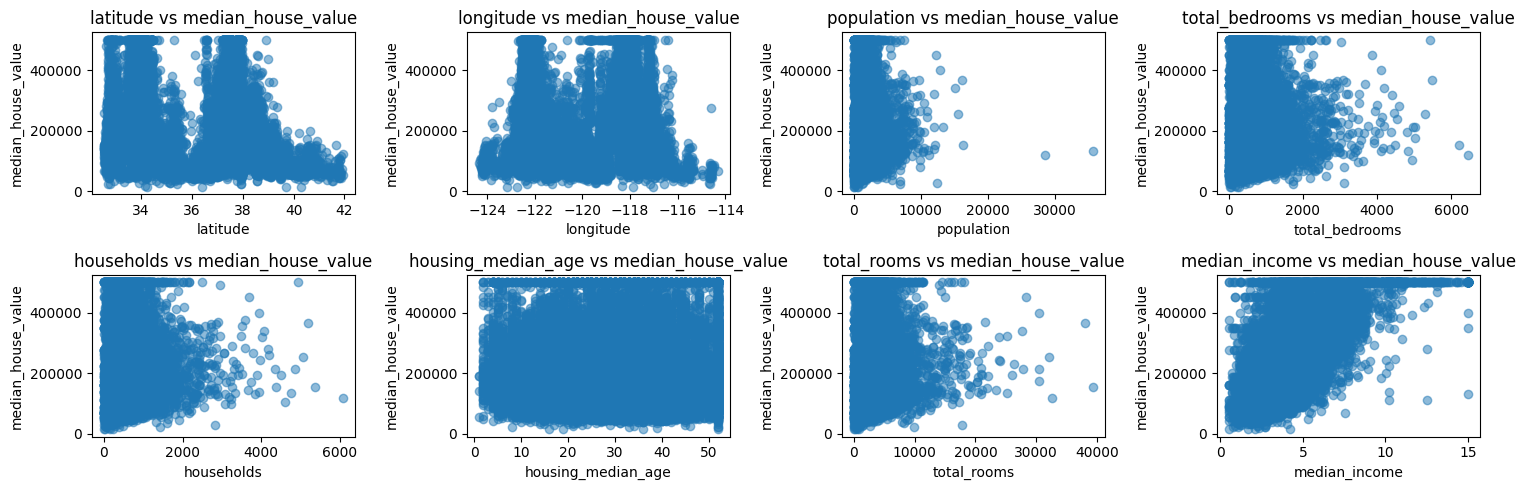

In [10]:
# Create scatter plots
fig, axes = plt.subplots(2, 4, figsize=(15, 5))
for i, feature in enumerate(correlations.index):
    axes.flat[i].scatter(df[feature], df['median_house_value'], alpha=0.5)
    axes.flat[i].set_xlabel(feature)
    axes.flat[i].set_ylabel('median_house_value')
    axes.flat[i].set_title(f'{feature} vs {'median_house_value'}')
plt.tight_layout()
plt.show()

In [11]:
# Create comprehensive scatter plots for top features
# this is what AI gave me 
'''
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

# Plot only numeric top features and match number of subplots
features_to_plot = correlations.index[:len(axes)]  # 6 features for 2x3 axes

for i, feature in enumerate(features_to_plot):
    x = numeric_df[feature]
    y = numeric_df['median_house_value']

    # Remove NaN/inf values for stats and fitting
    valid_mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)
    x_valid = x[valid_mask]
    y_valid = y[valid_mask]

    corr_coef, p_value = stats.pearsonr(x_valid, y_valid)

    axes[i].scatter(x_valid, y_valid, alpha=0.4, s=10, c='steelblue', edgecolors='none')

    z = np.polyfit(x_valid, y_valid, 1)
    p = np.poly1d(z)
    x_sorted = np.sort(x_valid.values)
    axes[i].plot(x_sorted, p(x_sorted), "r-", linewidth=2, label=f"Trend (slope={z[0]:.2f})")

    stats_text = f"r = {corr_coef:.3f}\np-value = {p_value:.4f}\nn = {len(x_valid):,}"
    axes[i].text(
        0.05, 0.95, stats_text, transform=axes[i].transAxes,
        fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8)
    )

    if feature == 'median_income':
        axes[i].set_xlabel('Median Income (tens of thousands)', fontsize=11)
    elif feature == 'housing_median_age':
        axes[i].set_xlabel('Housing Median Age (years)', fontsize=11)
    elif feature in ['total_rooms', 'total_bedrooms', 'population', 'households']:
        axes[i].set_xlabel(feature.replace('_', ' ').title(), fontsize=11)
        axes[i].set_xscale('log')

    axes[i].set_ylabel('Median House Value ($)', fontsize=11)
    axes[i].set_title(
        f"{feature.replace('_', ' ').title()} vs House Value\nCorrelation: {corr_coef:.3f}",
        fontsize=12, fontweight='bold'
    )
    axes[i].grid(True, alpha=0.3, linestyle='--')
    axes[i].legend(loc='lower right')

plt.suptitle(f'California Housing: Top Features vs Median House Value', 
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()
'''

'\nfig, axes = plt.subplots(2, 3, figsize=(18, 12))\naxes = axes.ravel()\n\n# Plot only numeric top features and match number of subplots\nfeatures_to_plot = correlations.index[:len(axes)]  # 6 features for 2x3 axes\n\nfor i, feature in enumerate(features_to_plot):\n    x = numeric_df[feature]\n    y = numeric_df[\'median_house_value\']\n\n    # Remove NaN/inf values for stats and fitting\n    valid_mask = x.notna() & y.notna() & np.isfinite(x) & np.isfinite(y)\n    x_valid = x[valid_mask]\n    y_valid = y[valid_mask]\n\n    corr_coef, p_value = stats.pearsonr(x_valid, y_valid)\n\n    axes[i].scatter(x_valid, y_valid, alpha=0.4, s=10, c=\'steelblue\', edgecolors=\'none\')\n\n    z = np.polyfit(x_valid, y_valid, 1)\n    p = np.poly1d(z)\n    x_sorted = np.sort(x_valid.values)\n    axes[i].plot(x_sorted, p(x_sorted), "r-", linewidth=2, label=f"Trend (slope={z[0]:.2f})")\n\n    stats_text = f"r = {corr_coef:.3f}\np-value = {p_value:.4f}\nn = {len(x_valid):,}"\n    axes[i].text(\n        0

In [89]:
# Missing values summary
print(df.isnull().sum())


longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


<Axes: xlabel='housing_median_age', ylabel='median_house_value'>

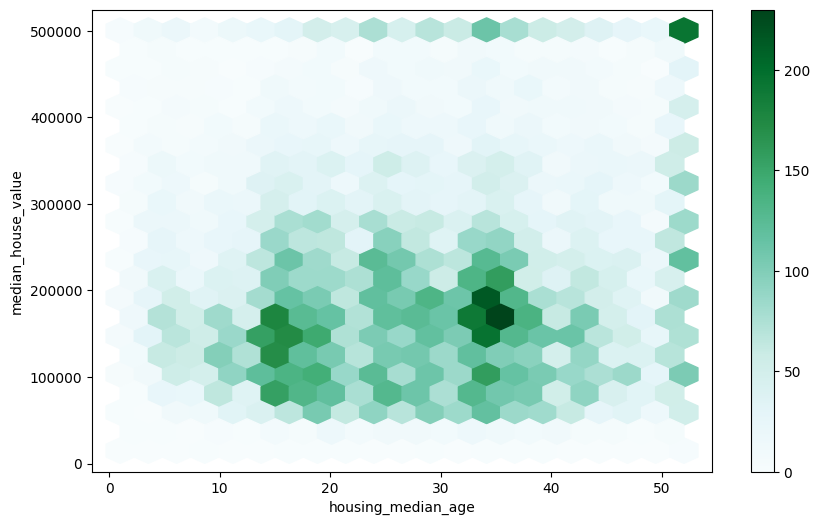

In [90]:
#BETTER THAN normal scatter plot
#it fixes the problem of the overplotting 
df.plot.hexbin(x='housing_median_age', y='median_house_value', gridsize=20, figsize=(10,6))

<Axes: xlabel='housing_median_age', ylabel='median_house_value'>

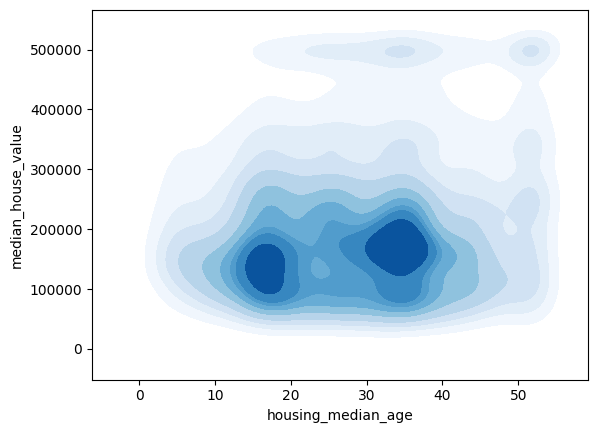

In [92]:
#this is better also (for density)
sns.kdeplot(data=df, x='housing_median_age', y='median_house_value', fill=True, cmap='Blues')
# 10-20 years are around 100k-200k
# 30-40 years are around 100k-200k but a bit higher
# 500k are genaraly old , concentred at 35 and +50

<Axes: ylabel='Frequency'>

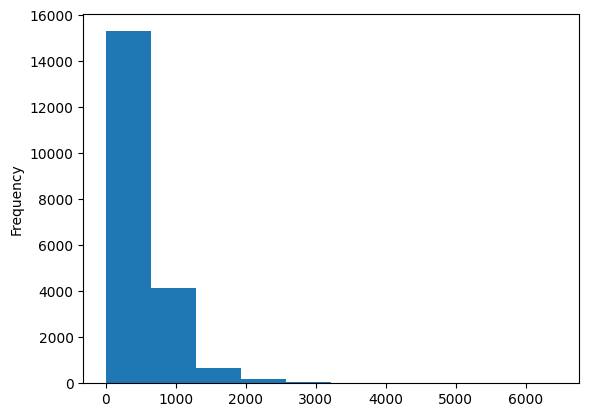

In [15]:
df['total_bedrooms'].plot(kind='hist')

<Axes: xlabel='ocean_proximity'>

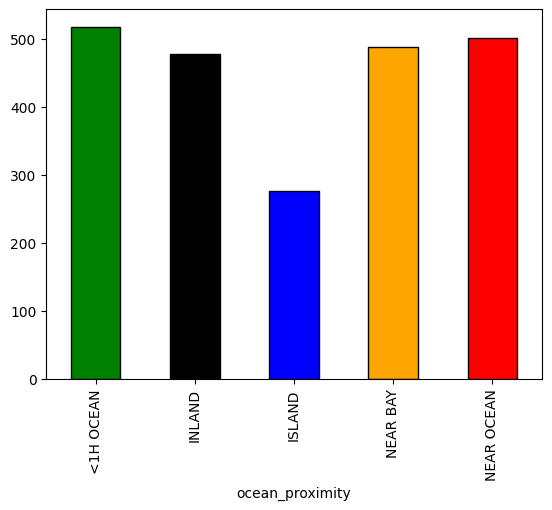

In [16]:
df.groupby('ocean_proximity')['households'].mean().plot(kind='bar', color=['green','black','blue', 'orange', 'red'], edgecolor='black')


<Axes: xlabel='ocean_proximity'>

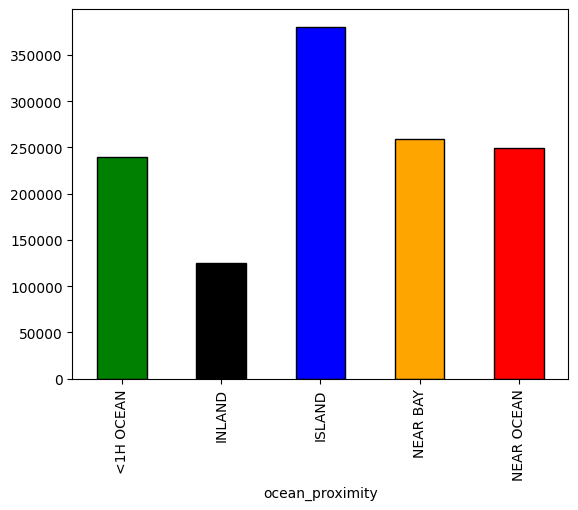

In [17]:
df.groupby('ocean_proximity')['median_house_value'].mean().plot(kind='bar', color=['green','black','blue', 'orange', 'red'], edgecolor='black')


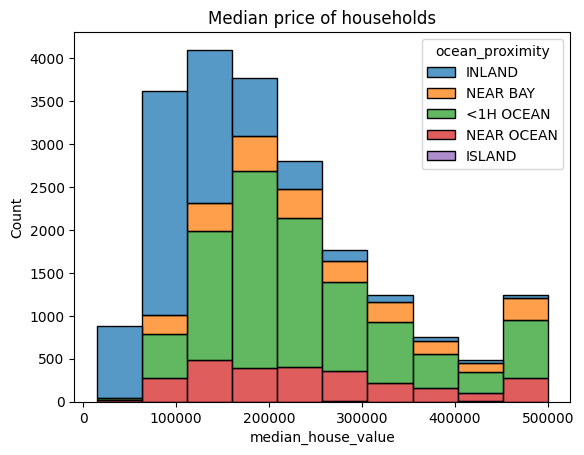

Island houses: are the most expensive
INLAND houses: most parts of them are the cheapest
NEAR BAY houses: they have all the prices
<1H OCEAN houses: they dominate the average
NEAR OCEAN houses: the same as the NEAR BAY


In [18]:
sns.histplot(
    data=df,
    x="median_house_value",
    hue="ocean_proximity",
    bins=10,
    multiple="stack"
)

plt.title("Median price of households")
plt.show()

print("Island houses: are the most expensive")
print("INLAND houses: most parts of them are the cheapest")
print("NEAR BAY houses: they have all the prices")
print("<1H OCEAN houses: they dominate the average")
print("NEAR OCEAN houses: the same as the NEAR BAY")
 

<Axes: xlabel='longitude', ylabel='latitude'>

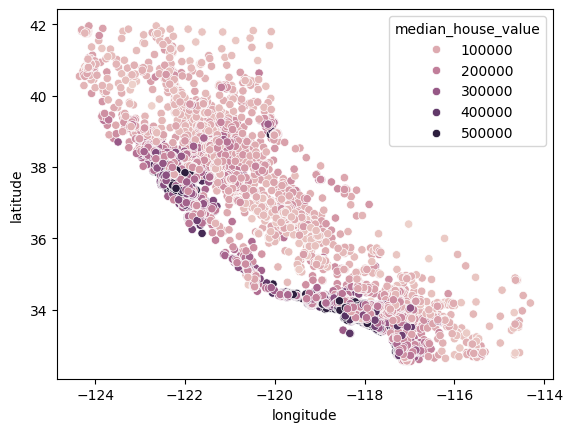

In [19]:
sns.scatterplot(x="longitude", y="latitude", hue="median_house_value", data=df)

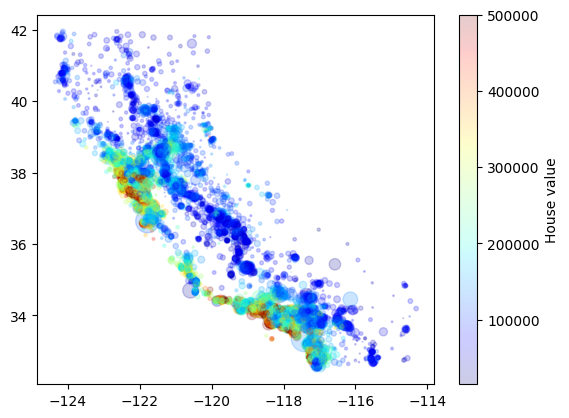

In [20]:
# very interesting !
# option s: radius of each circle represent the population/100
# option c: color represents the median price
#AI <This produces one of the most famous plots in machine learning>
plt.scatter(
df["longitude"],
df["latitude"],
alpha=0.2,
s=df["population"]/100,
c=df["median_house_value"],
cmap="jet")

plt.colorbar(label="House value")

### Initial Hypotheses
1. higher income means higher house value
2. ocean proximity: The closest you get to the ocean the more expensive the house it gits
3. 

## Step 3: Data Preparation (45 min) ⏱️

In [93]:
# Handle missing values
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [94]:
# since we have large data we can just delete the data 26k vs 207
df=df.dropna()

In [98]:
# Feature Engineering
'''
A very common ML pattern is:
Instead of using raw totals, use ratios.
'''
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,housing_layout,population_per_household,people_per_room,ocean_ISLAND,ocean_NEAR_OCEAN,ocean_<1H_OCEAN,ocean_NEAR_BAY,ocean_INLAND
207,-120.67,37.37,18.0,164.0,30.0,104.0,32.0,1.6607,87500.0,5.125000,0.182927,3.250000,0.634146,0,0,0,0,1
208,-118.01,33.89,34.0,1653.0,292.0,1003.0,310.0,4.6000,203400.0,5.332258,0.176649,3.235484,0.606776,0,0,1,0,0
209,-121.97,36.97,15.0,2849.0,668.0,1546.0,582.0,2.7587,228600.0,4.895189,0.234468,2.656357,0.542647,0,1,0,0,0
210,-118.25,33.98,47.0,617.0,162.0,754.0,144.0,2.2969,116700.0,4.284722,0.262561,5.236111,1.222042,0,0,1,0,0
211,-121.81,37.38,29.0,570.0,76.0,244.0,72.0,12.3292,416700.0,7.916667,0.133333,3.388889,0.428070,0,0,1,0,0


In [96]:
df['rooms_per_household'] = df['total_rooms']/df['households']
df['housing_layout'] = df['total_bedrooms']/df['total_rooms']
df['population_per_household'] = df['population']/df['households']
df['people_per_room'] = df['population']/df['total_rooms']

In [97]:
# Encoding categorical variables (ocean_proximity)

#this type of encoding is not working in our case , it s like saying 5*island = inland (no sense)
'''df['ocean_proximity']=df['ocean_proximity'].replace('ISLAND',1)
df['ocean_proximity']=df['ocean_proximity'].replace('NEAR OCEAN',2)
df['ocean_proximity']=df['ocean_proximity'].replace('<1H OCEAN',3)
df['ocean_proximity']=df['ocean_proximity'].replace('NEAR BAY',4)
df['ocean_proximity']=df['ocean_proximity'].replace('INLAND',5)'''

# best option is the one-hot encoding methode 
df['ocean_ISLAND'] = (df['ocean_proximity'] == 'ISLAND').astype(int)
df['ocean_NEAR_OCEAN'] = (df['ocean_proximity'] == 'NEAR OCEAN' ).astype(int)
df['ocean_<1H_OCEAN'] = (df['ocean_proximity'] == '<1H OCEAN' ).astype(int)
df['ocean_NEAR_BAY'] = (df['ocean_proximity'] == 'NEAR BAY' ).astype(int)
df['ocean_INLAND'] = (df['ocean_proximity'] == 'INLAND' ).astype(int)
df.drop(columns=['ocean_proximity'],inplace=True)

In [99]:
# Train/Validation split (70/15/15)

#shuffle
df_shuffle = df.sample(frac=1,random_state=42).reset_index(drop=True)

# fixe values
train_ratio = 0.7
validation_ratio = 0.15
test_ratio = 0.15
total_row = len(df_shuffle)
train_size = int(total_row * train_ratio)
validation_size = int(total_row * validation_ratio)
test_size = total_row - train_size - validation_size

# Split
train_set = df_shuffle[:train_size]
validation_set = df_shuffle[train_size:train_size+validation_size]
test_set = df_shuffle[train_size+validation_size:]

In [100]:
# Feature Scaling 
mean_age , std_age = train_set['housing_median_age'].mean() , train_set['housing_median_age'].std()
mean_longitude , std_longitude = train_set['longitude'].mean() , train_set['longitude'].std()
mean_latitude , std_latitude = train_set['latitude'].mean() , train_set['latitude'].std()
mean_total_rooms , std_total_rooms = train_set['total_rooms'].mean() , train_set['total_rooms'].std()
mean_total_bedrooms , std_total_bedrooms = train_set['total_bedrooms'].mean() , train_set['total_bedrooms'].std()
mean_population , std_population = train_set['population'].mean() , train_set['population'].std()
mean_households , std_households = train_set['households'].mean() , train_set['households'].std()
mean_median_income , std_median_income = train_set['median_income'].mean() , train_set['median_income'].std()
mean_rooms_per_household , std_rooms_per_household = train_set['rooms_per_household'].mean() , train_set['rooms_per_household'].std()
mean_housing_layout , std_housing_layout = train_set['housing_layout'].mean() , train_set['housing_layout'].std()
mean_population_per_household , std_population_per_household = train_set['population_per_household'].mean() , train_set['population_per_household'].std()
mean_people_per_room , std_people_per_room = train_set['people_per_room'].mean() , train_set['people_per_room'].std()

def scaling(X,m,st):
    return (X-m)/st

In [101]:
train_set['housing_median_age'],validation_set['housing_median_age'],test_set['housing_median_age'] = scaling(train_set['housing_median_age'],mean_age , std_age),scaling(validation_set['housing_median_age'],mean_age , std_age),scaling(test_set['housing_median_age'],mean_age , std_age)
train_set['longitude'],validation_set['longitude'],test_set['longitude'] = scaling(train_set['longitude'],mean_longitude , std_longitude),scaling(validation_set['longitude'],mean_longitude , std_longitude),scaling(test_set['longitude'],mean_longitude , std_longitude)
train_set['latitude'],validation_set['latitude'],test_set['latitude'] = scaling(train_set['latitude'],mean_latitude , std_latitude),scaling(validation_set['latitude'],mean_latitude , std_latitude),scaling(test_set['latitude'],mean_latitude , std_latitude)
train_set['total_rooms'],validation_set['total_rooms'],test_set['total_rooms'] = scaling(train_set['total_rooms'],mean_total_rooms , std_total_rooms),scaling(validation_set['total_rooms'],mean_total_rooms , std_total_rooms),scaling(test_set['total_rooms'],mean_total_rooms , std_total_rooms)
train_set['total_bedrooms'],validation_set['total_bedrooms'],test_set['total_bedrooms'] = scaling(train_set['total_bedrooms'],mean_total_bedrooms , std_total_bedrooms),scaling(validation_set['total_bedrooms'],mean_total_bedrooms , std_total_bedrooms),scaling(test_set['total_bedrooms'],mean_total_bedrooms , std_total_bedrooms)
train_set['population'],validation_set['population'],test_set['population'] = scaling(train_set['population'],mean_population , std_population),scaling(validation_set['population'],mean_population , std_population),scaling(test_set['population'],mean_population , std_population)
train_set['households'],validation_set['households'],test_set['households'] = scaling(train_set['households'],mean_households , std_households),scaling(validation_set['households'],mean_households , std_households),scaling(test_set['households'],mean_households , std_households)
train_set['median_income'],validation_set['median_income'],test_set['median_income'] = scaling(train_set['median_income'],mean_median_income , std_median_income),scaling(validation_set['median_income'],mean_median_income , std_median_income),scaling(test_set['median_income'],mean_median_income , std_median_income)
train_set['rooms_per_household'],validation_set['rooms_per_household'],test_set['rooms_per_household'] = scaling(train_set['rooms_per_household'],mean_rooms_per_household , std_rooms_per_household),scaling(validation_set['rooms_per_household'],mean_rooms_per_household , std_rooms_per_household),scaling(test_set['rooms_per_household'],mean_rooms_per_household , std_rooms_per_household)
train_set['housing_layout'],validation_set['housing_layout'],test_set['housing_layout'] = scaling(train_set['housing_layout'],mean_housing_layout , std_housing_layout),scaling(validation_set['housing_layout'],mean_housing_layout , std_housing_layout),scaling(test_set['housing_layout'],mean_housing_layout , std_housing_layout)
train_set['population_per_household'],validation_set['population_per_household'],test_set['population_per_household'] = scaling(train_set['population_per_household'],mean_population_per_household , std_population_per_household),scaling(validation_set['population_per_household'],mean_population_per_household , std_population_per_household),scaling(test_set['population_per_household'],mean_population_per_household , std_population_per_household)
train_set['people_per_room'],validation_set['people_per_room'],test_set['people_per_room'] = scaling(train_set['people_per_room'],mean_people_per_room , std_people_per_room),scaling(validation_set['people_per_room'],mean_people_per_room , std_people_per_room),scaling(test_set['people_per_room'],mean_people_per_room , std_people_per_room)


In [102]:
train_set.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,rooms_per_household,housing_layout,population_per_household,people_per_room,ocean_ISLAND,ocean_NEAR_OCEAN,ocean_<1H_OCEAN,ocean_NEAR_BAY,ocean_INLAND
count,1.430300e+04,1.430300e+04,1.430300e+04,1.430300e+04,1.430300e+04,1.430300e+04,1.430300e+04,1.430300e+04,14303.000000,1.430300e+04,1.430300e+04,1.430300e+04,1.430300e+04,14303.000000,14303.000000,14303.000000,14303.000000,14303.000000
mean,8.594273e-16,5.961346e-16,2.086471e-17,5.216178e-17,1.987115e-18,-1.291625e-17,5.563923e-17,-1.291625e-17,206960.907712,-1.222076e-16,1.341303e-17,-4.471009e-18,1.192269e-17,0.000140,0.128155,0.437041,0.114032,0.320632
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,115648.714256,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.011825,0.334274,0.496038,0.317861,0.466736
min,-2.378020e+00,-1.454705e+00,-2.197127e+00,-1.185857e+00,-1.255971e+00,-1.223558e+00,-1.286410e+00,-1.770345e+00,14999.000000,-1.660051e+00,-1.966188e+00,-1.963367e-01,-1.761704e-01,0.000000,0.000000,0.000000,0.000000,0.000000
25%,-1.105383e+00,-8.045853e-01,-8.459812e-01,-5.359414e-01,-5.684955e-01,-5.499413e-01,-5.686500e-01,-6.871997e-01,118900.000000,-3.666412e-01,-6.488426e-01,-5.513374e-02,-5.600278e-02,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5.315784e-01,-6.455633e-01,2.828976e-02,-2.302834e-01,-2.434644e-01,-2.280016e-01,-2.330068e-01,-1.761400e-01,180100.000000,-8.356586e-02,-1.680978e-01,-2.422494e-02,-3.302197e-02,0.000000,0.000000,0.000000,0.000000,0.000000
75%,7.861059e-01,9.727196e-01,6.641232e-01,2.255106e-01,2.499282e-01,2.546925e-01,2.678760e-01,4.649557e-01,266000.000000,2.153320e-01,4.638892e-01,1.332058e-02,7.480783e-03,0.000000,0.000000,1.000000,0.000000,1.000000
max,2.552826e+00,2.946463e+00,1.856311e+00,1.646152e+01,1.381238e+01,2.952836e+01,1.441394e+01,5.821958e+00,500001.000000,4.947118e+01,1.375260e+01,1.007184e+02,1.131489e+02,1.000000,1.000000,1.000000,1.000000,1.000000


## Step 4: Models FROM SCRATCH (90 min) ⏱️

### Model 1: Linear Regression from Scratch

In [71]:
# Linear Regression from scratch
# Two approaches: Normal Equation (analytical) and Gradient Descent

#Normal Equation (analytical)
'''
Theory:
The Normal Equation solves for θ directly using linear algebra by finding the derivative of the cost function and setting it to zero.

Cost function (Mean Squared Error):
J(θ) = (1/m) * Σ(hθ(xⁱ) - yⁱ)²

In matrix form:
J(θ) = (1/m) * (Xθ - y)ᵀ(Xθ - y)

Derivation:
Taking the derivative and setting to zero gives the closed-form solution:
θ = (XᵀX)⁻¹ Xᵀ y

Characteristics:
No iterations needed - calculates θ directly
Computational complexity: O(n³) for inverting XᵀX
Works well when n (number of features) is relatively small (< 10,000)
Requires (XᵀX) to be invertible (non-singular)
'''
#Gradient Descent
'''
Theory:
Gradient descent iteratively adjusts θ in the direction of steepest descent of the cost function.

Cost Function:
J(θ) = (1/2m) * Σ(hθ(xⁱ) - yⁱ)² # '1/2m' gives cleaner gradients

Update Rule:
For each parameter θⱼ simultaneously:
θⱼ := θⱼ - α * ∂J(θ)/∂θⱼ

The partial derivative is:
∂J(θ)/∂θⱼ = (1/m) * Σ(hθ(xⁱ) - yⁱ) * xⱼⁱ

Matrix Form Update:
θ := θ - (α/m) * Xᵀ(Xθ - y)

Key Components:
α (learning rate): Controls step size (too small = slow, too large = may not converge)
m: Number of training examples
Convergence criteria: Stop when change in J(θ) is below a threshold

Characteristics:
Iterative - requires many steps
Computational complexity per iteration: O(mn)
Works well even with large n
Requires feature scaling for faster convergence
Hyperparameters: learning rate, number of iterations
'''

"\nTheory:\nGradient descent iteratively adjusts θ in the direction of steepest descent of the cost function.\n\nCost Function:\nJ(θ) = (1/2m) * Σ(hθ(xⁱ) - yⁱ)² # '1/2m' gives cleaner gradients\n\nUpdate Rule:\nFor each parameter θⱼ simultaneously:\nθⱼ := θⱼ - α * ∂J(θ)/∂θⱼ\n\nThe partial derivative is:\n∂J(θ)/∂θⱼ = (1/m) * Σ(hθ(xⁱ) - yⁱ) * xⱼⁱ\n\nMatrix Form Update:\nθ := θ - (α/m) * Xᵀ(Xθ - y)\n\nKey Components:\nα (learning rate): Controls step size (too small = slow, too large = may not converge)\nm: Number of training examples\nConvergence criteria: Stop when change in J(θ) is below a threshold\n\nCharacteristics:\nIterative - requires many steps\nComputational complexity per iteration: O(mn)\nWorks well even with large n\nRequires feature scaling for faster convergence\nHyperparameters: learning rate, number of iterations\n"

In [103]:
#θ = (XᵀX)⁻¹ Xᵀ y

class L_reg_Normal():
    def __init__(self):
        self.theta = None
        self.use_pseudo_inverse = False
        
    def fit(self,X,Y):
        X=np.array(X)
        Y=np.array(Y)
        X_with_bias = np.c_[np.ones(X.shape[0]),X]
        try:
            self.theta = np.linalg.inv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ Y
            self.use_pseudo_inverse = False
            print("Used Normal Equation with inverse")
        except :
            self.theta = np.linalg.pinv(X_with_bias.T @ X_with_bias) @ X_with_bias.T @ Y
            self.use_pseudo_inverse = True
            print("Used Normal Equation with pseudo-inverse (XᵀX is singular)")
        return self

    
    def predict(self,X):
        X = np.array(X)
        X_with_bias = np.c_[np.ones(X.shape[0]),X]
        return X_with_bias @ self.theta
    
    def get_params(self):
        return self.theta

# Une matrice carrée est inversible si et seulement si son déterminant est non nul    
    def is_inversible(self,X):
        X=np.array(X)
        X_with_bias = np.c_[np.ones(X.shape[0]),X]
        XTX = X_with_bias.T @ X_with_bias
        det = np.linalg.det(XTX)
        return abs(det) > 1e-10

In [104]:
'''Update Rule:
For each parameter θⱼ simultaneously:
θⱼ := θⱼ - α * ∂J(θ)/∂θⱼ

The partial derivative is:
∂J(θ)/∂θⱼ = (1/m) * Σ(hθ(xⁱ) - yⁱ) * xⱼⁱ

Matrix Form Update:
θ := θ - (α/m) * Xᵀ(Xθ - y)'''
class L_reg_GD:
    def __init__(self,n_iter=10000,learning_rate=0.01):
        self.n_iter = n_iter
        self.learning_rate= learning_rate
        self.theta = None
        
    def fit(self,X,Y):
        X=np.array(X)
        Y=np.array(Y)
        X_with_bias = np.c_[np.ones(X.shape[0]),X]
        m=len(X_with_bias)
        n=X_with_bias.shape[1]
        self.theta = np.zeros(n)
        for i in range(self.n_iter):
            self.theta -= (self.learning_rate/m)*X_with_bias.T@(X_with_bias@self.theta-Y)
        return self
    
    def predict(self,X):
        X=np.array(X)
        X_with_bias = np.c_[np.ones(X.shape[0]),X]
        return X_with_bias @ self.theta
    
    def get_params(self):
        return self.theta

In [105]:
# Train Linear Regression
X_train = train_set.drop(columns=['median_house_value'])
Y_train = train_set['median_house_value']
X_validation = validation_set.drop(columns=['median_house_value'])
Y_validation = validation_set['median_house_value']
X_test = test_set.drop(columns=['median_house_value'])
Y_test = test_set['median_house_value']

In [106]:
X_train.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,rooms_per_household,housing_layout,population_per_household,people_per_room,ocean_ISLAND,ocean_NEAR_OCEAN,ocean_<1H_OCEAN,ocean_NEAR_BAY,ocean_INLAND
0,0.601449,-0.860711,0.346206,-0.132437,-0.306600,-0.405564,-0.325954,1.369003,0.301040,-0.686588,-0.044853,-0.064171,0,1,0,0,0
1,0.711245,-0.781200,0.346206,-0.649946,-0.526405,0.020241,-0.462793,-0.494018,-0.627199,0.858054,0.114916,0.168063,0,0,1,0,0
2,1.340078,-1.136661,-1.402335,0.667839,0.549237,0.506383,0.526063,-0.361494,0.148785,-0.445369,-0.020135,-0.040848,0,0,1,0,0
3,-1.110374,1.103679,1.856311,-0.682262,-0.685413,-0.772756,-0.705489,-0.846714,-0.179066,0.094223,-0.062830,-0.045807,0,0,0,0,1
4,-1.245123,1.075616,-0.369106,0.237405,0.023108,-0.063368,0.094891,0.621093,0.164053,-0.696333,-0.047868,-0.058499,0,0,0,1,0


In [107]:
model = L_reg_Normal()
model.fit(X_train,Y_train)
predictions = model.predict(X_validation)
params = model.get_params()

Used Normal Equation with inverse


In [108]:
model_GD = L_reg_GD()
model_GD.fit(X_train,Y_train)
model_GD.predict(X_validation)
model_GD.get_params()

array([168702.68358932, -52296.326279  , -52848.57176207,  13482.25117592,
         4981.0135129 ,   9355.78219538, -43495.0833908 ,  33881.57922835,
        77898.26794917,   6415.69361175,  14966.04607116,   8195.75874193,
        -8015.7141355 ,   3699.77234804,  55411.92169255,  49765.42260451,
        47323.16621055,  12502.40073367])

### Model 2: KNN Regressor from Scratch

In [ ]:
# KNN Regressor from scratch
# Same as KNN classifier but predict = mean of k nearest neighbors (not majority vote)

class KNN_reg():
    def __init__(self,k=5):
        self.k=k
        self.X=None
        self.Y=None
        
    def fit(self,X,Y):
        self.X=np.array(X)
        self.Y=np.array(Y)
        
    def predict(self,X):
        X=np.array(X)
        predictions = []
        for i in range(X.shape[0]):
            distances = []
            min_k = []
            for j in range(self.X.shape[0]):
                distances.append(sum(np.square(X[i]-self.X[j])))
            min_k = np.argsort(distances)[:self.k]
            p = self.Y[min_k].mean()
            predictions.append(p)
        return predictions
                

In [110]:
# Train KNN Regressor
model_KNN = KNN_reg()
model_KNN.fit(X_train,Y_train)
model_KNN.predict(X_validation)


[np.float64(273420.0),
 np.float64(267840.0),
 np.float64(170600.0),
 np.float64(362040.2),
 np.float64(288960.0),
 np.float64(167460.0),
 np.float64(187200.0),
 np.float64(124880.0),
 np.float64(79260.0),
 np.float64(278860.0),
 np.float64(175620.0),
 np.float64(142880.0),
 np.float64(276120.0),
 np.float64(377920.2),
 np.float64(394380.2),
 np.float64(292940.0),
 np.float64(96720.0),
 np.float64(106000.0),
 np.float64(278440.2),
 np.float64(130740.0),
 np.float64(87820.0),
 np.float64(82020.0),
 np.float64(244500.0),
 np.float64(135480.0),
 np.float64(443320.4),
 np.float64(102040.0),
 np.float64(254100.0),
 np.float64(170480.0),
 np.float64(132300.0),
 np.float64(130780.0),
 np.float64(435100.0),
 np.float64(70660.0),
 np.float64(160000.0),
 np.float64(300620.2),
 np.float64(226680.0),
 np.float64(267920.0),
 np.float64(266420.0),
 np.float64(69680.0),
 np.float64(491240.6),
 np.float64(116040.0),
 np.float64(255900.2),
 np.float64(361980.0),
 np.float64(299780.0),
 np.float64(13712

### Model 3: Decision Tree Regressor from Scratch

In [118]:
# Decision Tree Regressor from scratch
# Same structure as classifier but: predict = mean(y) at leaf, split criterion = MSE reduction
class DT_reg():
    def __init__(self,max_depth,min_samples):
        self.max_depth = max_depth
        self.min_samples = min_samples
        self.tree = None
        
    def MSE(self,Y):
        Y=np.array(Y)
        n=len(Y)
        MSE = (1/n)*np.sum(np.square(Y-Y.mean()))
        return MSE
        
    def best_split(self,X,Y):
        best_feature = 0
        best_threshold = 0
        best_mse = np.inf
        for col in range(X.shape[1]):
            thresholds = np.unique(X[:,col])
            for j in thresholds:
                A=np.where(X[:,col] >= j)[0]
                B=np.where(X[:,col] < j)[0]
                if len(A)==0 or len(B)==0:continue
                MSE_t = (len(A)/X.shape[0]) * self.MSE(Y[A]) + (len(B)/X.shape[0]) * self.MSE(Y[B])
                if MSE_t < best_mse:
                    best_mse = MSE_t
                    best_feature = col
                    best_threshold = j
        return best_feature , best_threshold
    
    def _build_tree(self,X,Y,depth=0):
        if depth > self.max_depth or len(Y) <= self.min_samples or self.MSE(Y)==0:
            return {'value':Y.mean()}
        else:
            tree = {}
            best_feature , best_threshold = self.best_split(X,Y)
            #{"feature": ..., "threshold": ..., "left": ..., "right": ...}
            tree["feature"] = best_feature
            tree["threshold"] = best_threshold
            X_left = np.where( X[:,best_feature] < best_threshold )[0]
            X_right = np.where( X[:,best_feature] >= best_threshold )[0]
            Y_left = Y[X_left]
            Y_right = Y[X_right]
            tree["left"] = self._build_tree(X[X_left],Y_left,depth+1)
            tree["right"] = self._build_tree(X[X_right],Y_right,depth+1)
            return tree
        
    def fit(self,X,Y):
        X=np.array(X)
        Y= np.array(Y)
        self.tree = self._build_tree(X,Y)

    def _predict_one(self,x,node=None):
        if node is None:
            node = self.tree
        if 'value' in node :
            return node['value']
        if x[node['feature']] >= node['threshold']:
            return self._predict_one(x, node['right'])
        return self._predict_one(x, node['left'])
        
    def predict(self,X):
        X=np.array(X)
        predictions = []
        for x in X:
            predictions.append(self._predict_one(x))
        return np.array(predictions)

In [119]:
# Train Decision Tree Regressor
model_DT = DT_reg(10,5)
model_DT.fit(X_train,Y_train)
model_DT.predict(X_validation)


array([462850.75      , 236890.91818182, 125042.85714286, ...,
       500001.        ,  92685.61643836, 263868.        ], shape=(3064,))

## Step 5: Evaluation (30 min) ⏱️

In [33]:
# Regression Metrics from scratch: MSE, RMSE, MAE, R²

In [34]:
# Evaluate all 3 models

In [35]:
# Visualize: predicted vs actual scatter plot + residuals

## Step 6: Write-up ⏱️

### Key Findings
1. 
2. 
3. 

### What I'd do with more time
- 

### One thing I learned today
- 

### Where I got stuck
- 

## 🎯 BONUS (if time remains)
- [ ] Polynomial features from scratch
- [ ] Ridge Regression (L2 regularization) from scratch
- [ ] Plot learning curves (train vs val error over training set size)
- [ ] Try log-transforming the target (house prices are right-skewed)
- [ ] Residual analysis: are errors normally distributed?